# RCWA Bloch：倒格平移与快速角度扫描（1D 验证 + 2D 速度）

前三章用 **1D** 光栅把 g_shift / 收敛 / $N+M$ 说清楚；第 4 章改用 **2D** 圆盘截断，让本征分解耗时可见。


In [1]:
from __future__ import annotations

import math
import os
import sys
import time
from pathlib import Path

import matplotlib
from matplotlib import font_manager
import matplotlib.pyplot as plt
import numpy as np

# Plot labels in this notebook use ASCII/English to avoid CJK tofu.
# Keep a CJK font in the fallback list for any incidental Chinese glyphs.
for fp in (
    "/usr/share/fonts/truetype/droid/DroidSansFallbackFull.ttf",
    "/usr/share/fonts/truetype/arphic/uming.ttc",
):
    if os.path.isfile(fp):
        try:
            font_manager.fontManager.addfont(fp)
        except Exception:
            pass
matplotlib.rcParams["font.sans-serif"] = [
    "DejaVu Sans",
    "Droid Sans Fallback",
    "AR PL UMing CN",
    "sans-serif",
]
matplotlib.rcParams["axes.unicode_minus"] = False

ROOT = Path("/home/like/repos/simulation_toykits/simulation_core")
BUILD = Path(os.environ.get("SIMULATION_ARTIFACTS_DIR", ROOT / "build")).resolve()
if str(BUILD) not in sys.path:
    sys.path.insert(0, str(BUILD))

import simulation as sim

print("BUILD =", BUILD)
assert hasattr(sim, "make_rcwa_floquet_session_d")
assert hasattr(sim, "rcwa_fields_on_grid_floquet_d")
assert hasattr(sim, "rcwa_reciprocal_Lk_d")


BUILD = /home/like/repos/simulation_toykits/simulation_core/build


## 0. 工具函数与 1D 光栅

- `harmonic_G_1d(N)`：半宽 $N$ 的 1D G 表
- `k_inc_from_angle`：自算 $k_\parallel$
- `expansion_order_for_anchor`：返回 $N_{\mathrm{eff}}=N+M$


In [2]:
PI = math.pi


def harmonic_G_1d(N: int):
    """1D truncation half-width N -> G list length 2N+1."""
    N = int(N)
    if N < 0:
        raise ValueError("N must be >= 0")
    G = [(0, 0)]
    for i in range(1, N + 1):
        G.append((i, 0))
        G.append((-i, 0))
    return G


def k_inc_from_angle(theta_deg, wl_um, n=1.0, phi_deg=0.0):
    """Same formula as C++ k_incident_xy for isotropic front medium."""
    omega = 2.0 * PI / float(wl_um)
    th = math.radians(theta_deg)
    ph = math.radians(phi_deg)
    s0 = math.sin(th)
    return (math.cos(ph) * s0 * n * omega, math.sin(ph) * s0 * n * omega)


def theta_from_kx(kx, wl_um, n=1.0):
    omega = 2.0 * PI / float(wl_um)
    arg = float(kx) / (n * omega)
    if abs(arg) > 1.0 + 1e-12:
        raise ValueError(f"kx not propagating: {kx} vs n*omega={n * omega}")
    return math.degrees(math.asin(max(-1.0, min(1.0, arg))))


def expansion_order_for_anchor(
    theta_min,
    theta_max,
    N,
    wl_um,
    period,
    n=1.0,
    phi_deg=0.0,
    anchor_theta=None,
):
    """Given half-width N (accuracy vs truth for each angle's own ±N window),
    return N_eff = N + M for a specular-centered expansion at anchor a without g_shift.

    M = ceil(max_|theta| |kx(theta)-kx(a)| / (2π/Λ)).
    Extra orders form a superset and only move closer to the infinite-N truth.
    """
    if anchor_theta is None:
        anchor_theta = 0.5 * (float(theta_min) + float(theta_max))
    ka_x, _ = k_inc_from_angle(anchor_theta, wl_um, n, phi_deg)
    dk = 2.0 * PI / float(period)
    thetas = list(np.linspace(theta_min, theta_max, 64))
    M = 0
    for th in thetas:
        kx, _ = k_inc_from_angle(th, wl_um, n, phi_deg)
        M = max(M, int(math.ceil(abs(kx - ka_x) / dk - 1e-12)))
    N_eff = int(N) + int(M)
    return {
        "N": int(N),
        "M": int(M),
        "N_eff": N_eff,
        "anchor_theta_deg": float(anchor_theta),
        "n_basis": 2 * N_eff + 1,
        "dk": dk,
        "ka_x": ka_x,
    }


def mat_eps(eps, name):
    return sim.share_material_d(sim.material_d.from_epsilon(eps, name))


def make_grating_stack():
    vac = mat_eps(1 + 0j, "Vacuum")
    si = mat_eps(12 + 0j, "Silicon")
    above = sim.layer_d()
    above.background_material = vac
    above.depth = 0.0
    slab = sim.layer_d()
    slab.background_material = vac
    slab.depth = 0.5
    slab.shapes = [sim.make_rect_shape_d([0.25, 0.5], [0.0, 0.0], 0.0, si)]
    slab.parent = [-1]
    below = sim.layer_d()
    below.background_material = vac
    below.depth = 0.0
    return [above, slab, below]


def rel_err(a, b):
    a = np.asarray(a)
    b = np.asarray(b)
    denom = max(float(np.max(np.abs(a))), float(np.max(np.abs(b))), 1e-30)
    return float(np.max(np.abs(a - b)) / denom)


def align_envelope_b_to_a(field_b, m, period):
    field_b = np.asarray(field_b)
    nx = field_b.shape[1]
    x = (np.arange(nx, dtype=float) / float(nx)) * float(period)
    phase = np.exp(2j * PI * m * x / period)
    return field_b * phase[None, :, None]


def n_G_from_halfwidth(N):
    return 2 * int(N) + 1


PERIOD = 1.0
LR = [PERIOD, 0.0, 0.0, 0.0]
WL = 0.8
N0 = 1.0
M_ORDER = 1
POL = "s"
WHICH = 1
ZOFF = 0.25

ka_x = -0.5 * M_ORDER * (2 * PI / PERIOD)
kb_x = ka_x + M_ORDER * (2 * PI / PERIOD)
THETA_A = theta_from_kx(ka_x, WL, N0)
THETA_B = theta_from_kx(kb_x, WL, N0)
print(f"theta_a={THETA_A:.4f} deg, theta_b={THETA_B:.4f} deg")
print("Lk =", list(sim.rcwa_reciprocal_Lk_d(LR)))
print(expansion_order_for_anchor(-25, 25, N=5, wl_um=WL, period=PERIOD, n=N0, anchor_theta=THETA_A))


theta_a=-23.5782 deg, theta_b=23.5782 deg
Lk = [1.0, 0.0, 0.0, 0.0]
{'N': 5, 'M': 2, 'N_eff': 7, 'anchor_theta_deg': -23.578178478201835, 'n_basis': 15, 'dk': 6.283185307179586, 'ka_x': -3.141592653589793}


## 1. 做 g_shift：误差 vs $N$（机器精度）

固定绝对 `k_list`：baseline = $b$ 上 drive 0 + `g_shift=(-m,0)`；待测 = $a$ 上 drive $m$。
包络相位对齐后画相对误差。


N= 2 n_G= 5: err_E=3.343e-16 err_H=5.620e-16
N= 3 n_G= 7: err_E=3.101e-16 err_H=6.183e-16
N= 4 n_G= 9: err_E=7.094e-16 err_H=5.054e-16
N= 5 n_G=11: err_E=4.423e-16 err_H=5.443e-16
N= 6 n_G=13: err_E=4.957e-16 err_H=4.748e-16
N= 7 n_G=15: err_E=3.685e-16 err_H=4.447e-16
N= 8 n_G=17: err_E=4.922e-16 err_H=3.867e-16
N= 9 n_G=19: err_E=4.120e-16 err_H=4.373e-16
N=10 n_G=21: err_E=3.401e-14 err_H=2.490e-14
N=11 n_G=23: err_E=4.910e-14 err_H=5.105e-14
N=12 n_G=25: err_E=9.048e-14 err_H=7.329e-14
N=13 n_G=27: err_E=7.466e-14 err_H=5.213e-14
N=14 n_G=29: err_E=2.234e-14 err_H=3.133e-14
N=15 n_G=31: err_E=1.265e-13 err_H=8.657e-14
§1 OK: machine-precision platform


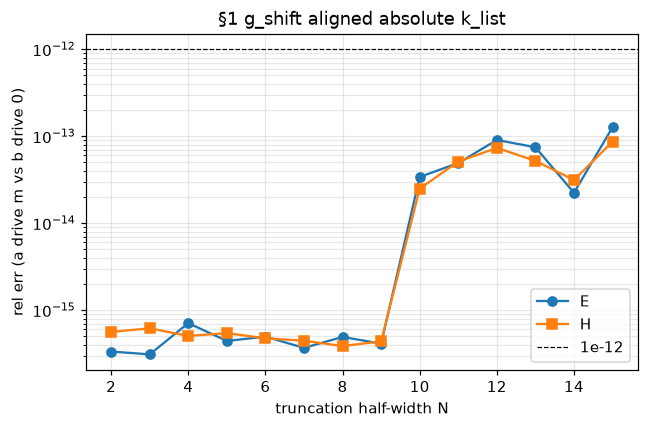

In [3]:
Ns = list(range(2, 16))
err_E = []
err_H = []
for N in Ns:
    n_G = n_G_from_halfwidth(N)
    nx = max(32, 2 * N + 8)
    nxy = [nx, 1]
    Eb, Hb = sim.rcwa_fields_on_grid_floquet_d(
        make_grating_stack(), WL, nxy, n_G=n_G, Lr=LR,
        k_inc=[kb_x, 0.0], drive_order=[0, 0], g_shift=[-M_ORDER, 0],
        pol=POL, which_layer=WHICH, z_offset=ZOFF,
        pol_theta_deg=THETA_B, pol_phi_deg=0.0,
    )
    Ea, Ha = sim.rcwa_fields_on_grid_floquet_d(
        make_grating_stack(), WL, nxy, n_G=n_G, Lr=LR,
        k_inc=[ka_x, 0.0], drive_order=[M_ORDER, 0], g_shift=[0, 0],
        pol=POL, which_layer=WHICH, z_offset=ZOFF,
        pol_theta_deg=THETA_B, pol_phi_deg=0.0,
    )
    err_E.append(rel_err(Ea, align_envelope_b_to_a(Eb, M_ORDER, PERIOD)))
    err_H.append(rel_err(Ha, align_envelope_b_to_a(Hb, M_ORDER, PERIOD)))
    print(f"N={N:2d} n_G={n_G:2d}: err_E={err_E[-1]:.3e} err_H={err_H[-1]:.3e}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogy(Ns, err_E, "o-", label="E")
ax.semilogy(Ns, err_H, "s-", label="H")
ax.axhline(1e-12, color="k", ls="--", lw=0.8, label="1e-12")
ax.set_xlabel("truncation half-width N")
ax.set_ylabel("rel err (a drive m vs b drive 0)")
ax.set_title("§1 g_shift aligned absolute k_list")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()
assert max(err_E) < 1e-10 and max(err_H) < 1e-10
print("§1 OK: machine-precision platform")


## 2. 不做 g_shift：相对高 $N_{\mathrm{ref}}$ 的收敛曲线

每角默认镜面对称 $\pm N$（`g_shift=0`）。以同一角上 $N_{\mathrm{ref}}$ 的场为真值代理。


N= 2: err vs N_ref=30 -> 6.260e-01
N= 4: err vs N_ref=30 -> 4.149e-01
N= 6: err vs N_ref=30 -> 2.988e-02
N= 8: err vs N_ref=30 -> 1.212e-02
N=10: err vs N_ref=30 -> 6.308e-03
N=12: err vs N_ref=30 -> 3.655e-03
N=14: err vs N_ref=30 -> 2.228e-03
N=16: err vs N_ref=30 -> 1.386e-03
N=18: err vs N_ref=30 -> 9.877e-04
N=20: err vs N_ref=30 -> 7.033e-04
N=22: err vs N_ref=30 -> 5.986e-04
N=24: err vs N_ref=30 -> 4.271e-04
N=26: err vs N_ref=30 -> 2.467e-04
N=28: err vs N_ref=30 -> 1.323e-04


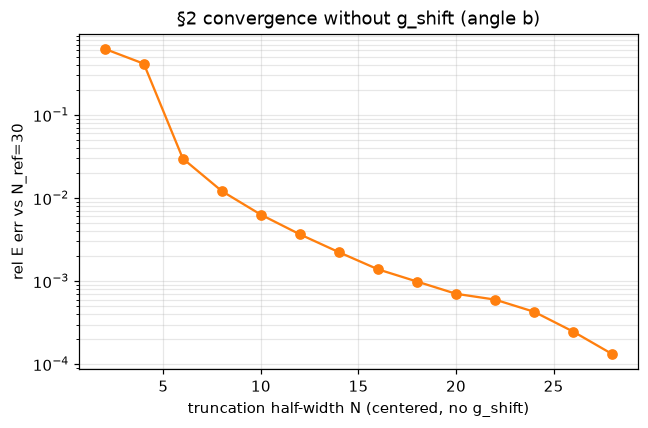

In [4]:
N_ref = 30
n_G_ref = n_G_from_halfwidth(N_ref)
nx_ref = max(64, 2 * N_ref + 8)
nxy_ref = [nx_ref, 1]

E_ref, _ = sim.rcwa_fields_on_grid_floquet_d(
    make_grating_stack(), WL, nxy_ref, n_G=n_G_ref, Lr=LR,
    k_inc=[kb_x, 0.0], drive_order=[0, 0], g_shift=[0, 0],
    pol=POL, which_layer=WHICH, z_offset=ZOFF,
    pol_theta_deg=THETA_B, pol_phi_deg=0.0,
)
E_ref = np.asarray(E_ref)

Ns2 = list(range(2, N_ref, 2))
conv_E = []
for N in Ns2:
    n_G = n_G_from_halfwidth(N)
    E_N, _ = sim.rcwa_fields_on_grid_floquet_d(
        make_grating_stack(), WL, nxy_ref, n_G=n_G, Lr=LR,
        k_inc=[kb_x, 0.0], drive_order=[0, 0], g_shift=[0, 0],
        pol=POL, which_layer=WHICH, z_offset=ZOFF,
        pol_theta_deg=THETA_B, pol_phi_deg=0.0,
    )
    conv_E.append(rel_err(E_N, E_ref))
    print(f"N={N:2d}: err vs N_ref={N_ref} -> {conv_E[-1]:.3e}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogy(Ns2, conv_E, "o-", color="C1")
ax.set_xlabel("truncation half-width N (centered, no g_shift)")
ax.set_ylabel(f"rel E err vs N_ref={N_ref}")
ax.set_title("§2 convergence without g_shift (angle b)")
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
plt.show()


## 3. $N+M$ 展开阶

给定角度范围与用户精度半宽 $N$（「对该角用 $\pm N$ 已够接近真值」），
不做对称窗对齐时，锚点 $a$ 应用 $N_{\mathrm{eff}}=N+M$ 以覆盖最远角的绝对通道。
多出的阶是超集，只会更靠近真值。


{'N': 3, 'M': 2, 'N_eff': 5, 'anchor_theta_deg': -23.578178478201835, 'n_basis': 11, 'dk': 6.283185307179586, 'ka_x': -3.141592653589793}
{'N': 5, 'M': 2, 'N_eff': 7, 'anchor_theta_deg': -23.578178478201835, 'n_basis': 15, 'dk': 6.283185307179586, 'ka_x': -3.141592653589793}
{'N': 10, 'M': 2, 'N_eff': 12, 'anchor_theta_deg': -23.578178478201835, 'n_basis': 25, 'dk': 6.283185307179586, 'ka_x': -3.141592653589793}
{'N': 15, 'M': 2, 'N_eff': 17, 'anchor_theta_deg': -23.578178478201835, 'n_basis': 35, 'dk': 6.283185307179586, 'ka_x': -3.141592653589793}
interval coverage OK: (-28.09669047000426, 34.73516260179161) subset (-47.12388980384689, 40.840704496667314)


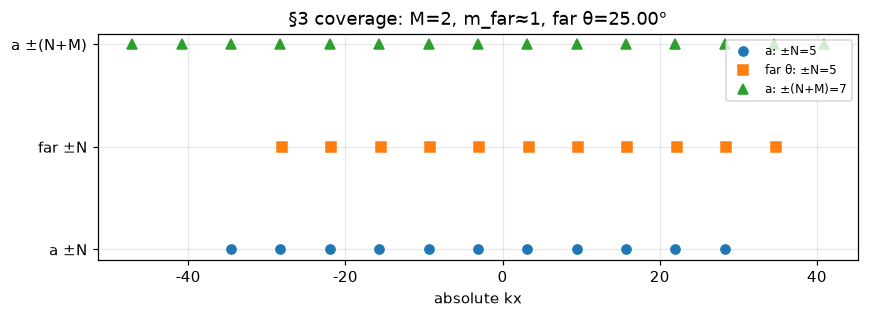

In [5]:
theta_min, theta_max = -25.0, 25.0

for N in (3, 5, 10, 15):

    info = expansion_order_for_anchor(

        theta_min, theta_max, N=N, wl_um=WL, period=PERIOD, n=N0, anchor_theta=THETA_A

    )

    print(info)



info = expansion_order_for_anchor(

    theta_min, theta_max, N=5, wl_um=WL, period=PERIOD, n=N0, anchor_theta=THETA_A

)

assert info["N_eff"] == info["N"] + info["M"]

assert info["M"] >= 1



N_user = 5

M = info["M"]

N_eff = info["N_eff"]

dk = info["dk"]

ka = info["ka_x"]





def abs_set(kinc, half):

    return sorted([kinc + g * dk for g in range(-half, half + 1)])





th_far = theta_max if abs(k_inc_from_angle(theta_max, WL, N0)[0] - ka) >= abs(

    k_inc_from_angle(theta_min, WL, N0)[0] - ka

) else theta_min

kx_far, _ = k_inc_from_angle(th_far, WL, N0)

m_far = int(round((kx_far - ka) / dk))



Sa_small = abs_set(ka, N_user)

Sb = abs_set(kx_far, N_user)

Sa_eff = abs_set(ka, N_eff)



fig, ax = plt.subplots(figsize=(8, 3))

ax.plot(Sa_small, np.zeros(len(Sa_small)), "o", label=f"a: ±N={N_user}")

ax.plot(Sb, np.ones(len(Sb)), "s", label=f"far θ: ±N={N_user}")

ax.plot(Sa_eff, np.ones(len(Sa_eff)) * 2, "^", label=f"a: ±(N+M)={N_eff}")

ax.set_yticks([0, 1, 2])

ax.set_yticklabels(["a ±N", "far ±N", "a ±(N+M)"])

ax.set_xlabel("absolute kx")

ax.set_title(f"§3 coverage: M={M}, m_far≈{m_far}, far θ={th_far:.2f}°")

ax.grid(True, alpha=0.3)

ax.legend(loc="upper right", fontsize=8)

fig.tight_layout()

plt.show()



# Interval coverage (far specular need not sit on anchor lattice point)

span_b = (kx_far - N_user * dk, kx_far + N_user * dk)

span_a = (ka - N_eff * dk, ka + N_eff * dk)

assert span_a[0] <= span_b[0] + 1e-9 and span_a[1] >= span_b[1] - 1e-9

print("interval coverage OK:", span_b, "subset", span_a)



## 4. 2D：速度 + 空域能量分布 RMS

`fields_on_grid` → 空域 $E(x,y)$（IFFT）。$U=\sum_c|E_c|^2$，画图前 `fftshift`。

- **速度**：中等 $N_{\mathrm{eff}}$
- **能量**：较大 $N$；子图按 $(m,n)$ 排布，**(0,0) 居中**
- **两套色图**：Baseline A 与仿真 Fast B（同一 colorbar 范围，便于目视对比）+ RMS 曲线


speed disk N_eff=8 (197); energy N=10 (317), N_eff=12 (441); angles=13
Speed (identical N_eff basis, 13 angles): A=24.512s (eigen 3.809 + field 20.703) | B=1.999s (eigen 0.299 + field 1.699)
total speedup=12.26x | eigen-only=12.7x | reuse max L2=0.000e+00  (eigen+cascade reuse check, expect ~0)

Energy RMS (converged N=10, N_eff=12): U=|E|^2 ; baseline=A, fast=B
  m   n    theta      phi  RMS(U_B-U_A)/RMS(U_A)
 -2   0    36.87   180.00              1.714e-02
 -1  -1    25.10  -135.00              1.833e-02
 -1   0    17.46   180.00              1.368e-02
 -1   1    25.10   135.00              1.833e-02
  0  -2    36.87   -90.00              1.714e-02
  0  -1    17.46   -90.00              1.368e-02
  0   0     0.00     0.00              1.342e-02
  0   1    17.46    90.00              1.368e-02
  0   2    36.87    90.00              1.714e-02
  1  -1    25.10   -45.00              1.833e-02
  1   0    17.46     0.00              1.368e-02
  1   1    25.10    45.00              1.833e-0

c11:281: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


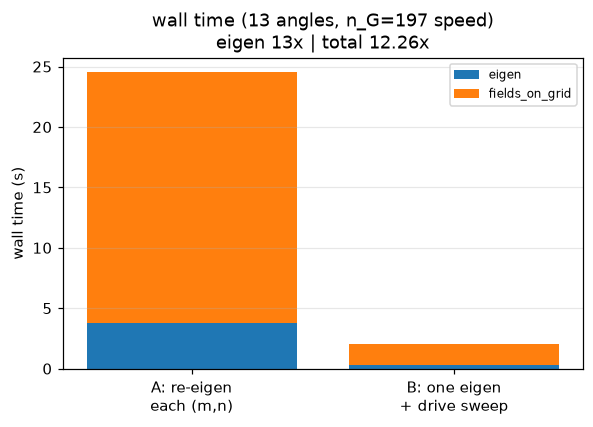

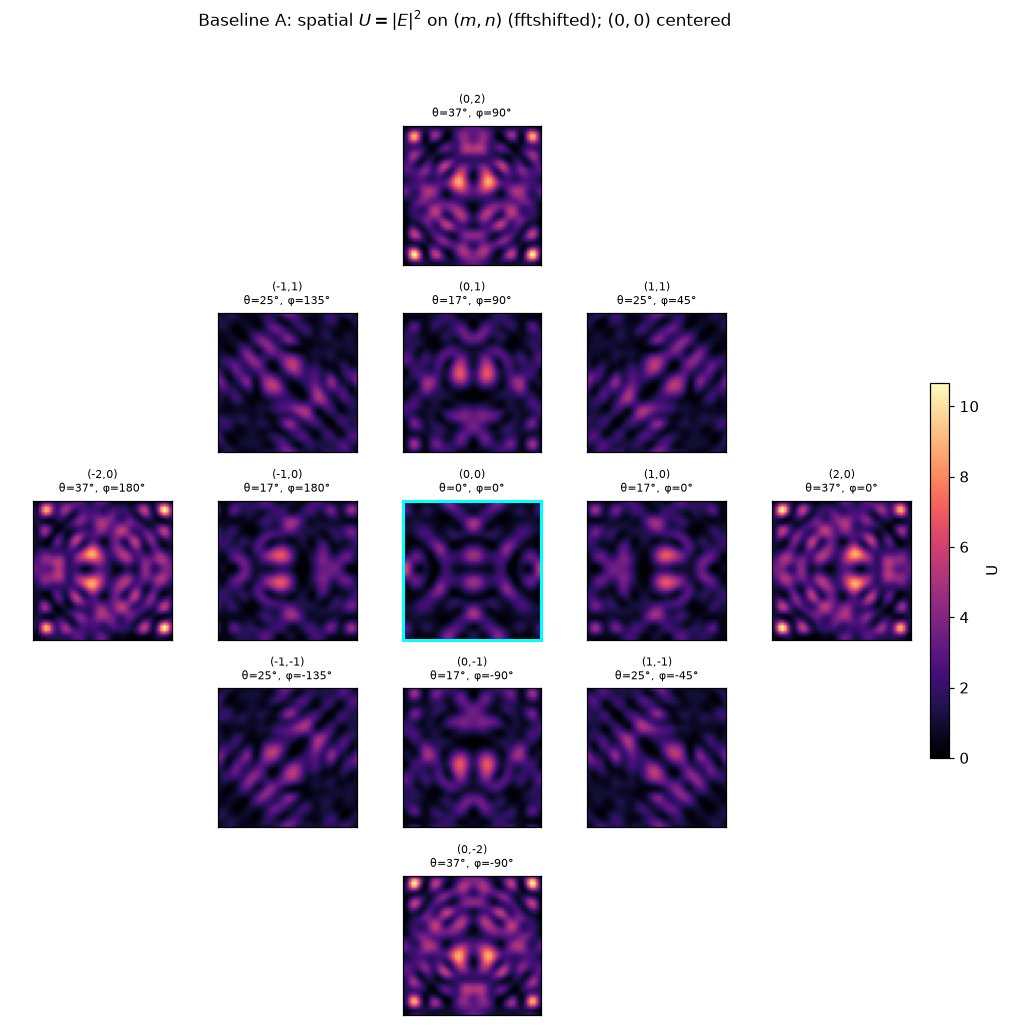

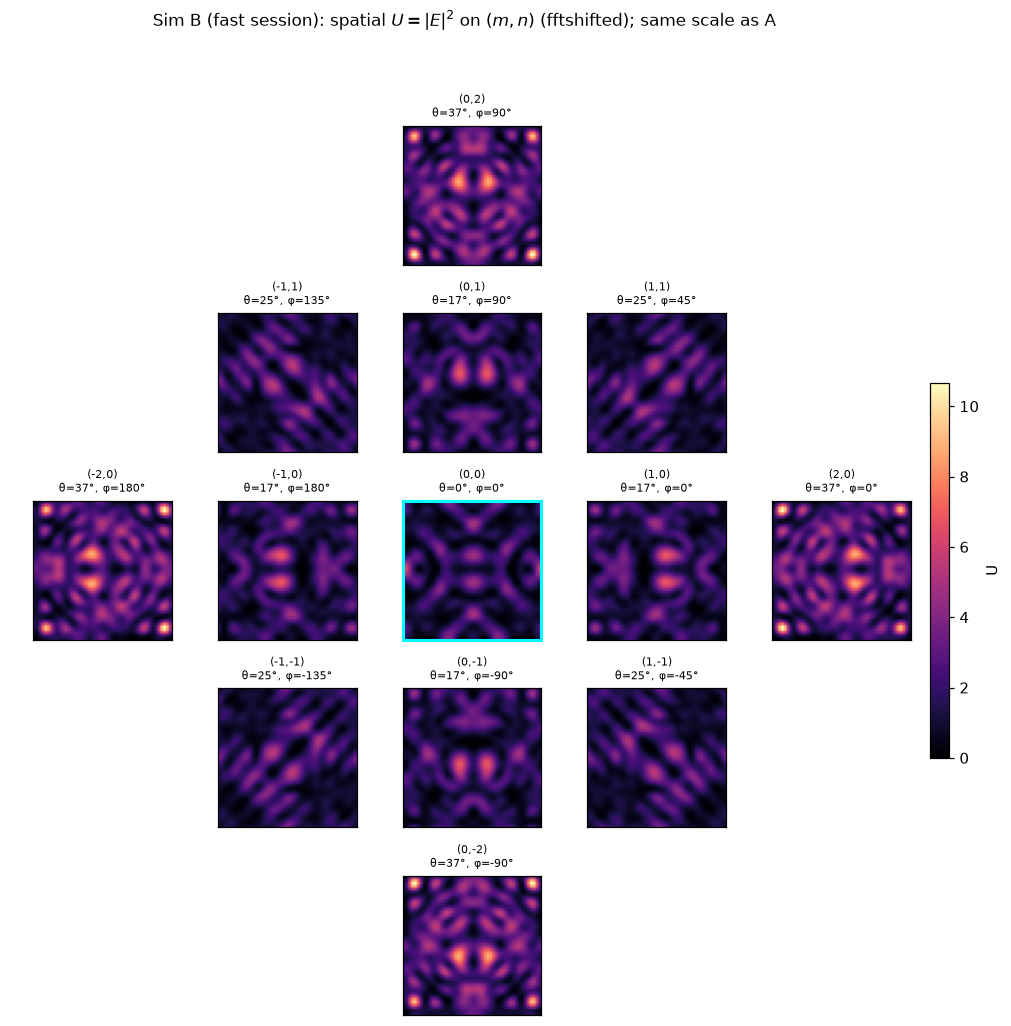

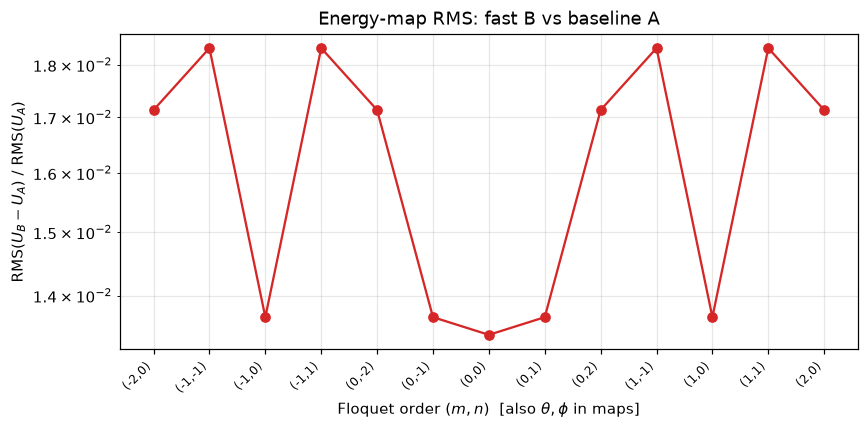

In [6]:
def harmonic_G_disk(N: int):
    """2D circular truncation: m^2 + n^2 <= N^2."""
    N = int(N)
    return [(m, n) for m in range(-N, N + 1) for n in range(-N, N + 1) if m * m + n * n <= N * N]


def make_2d_stack(eps_hi=2.25 + 0j, radius=0.30, depth=0.50, tag="s4"):
    """Square-lattice circular hole (moderate contrast → fields converge better)."""
    vac = mat_eps(1 + 0j, f"vac_{tag}")
    hi = mat_eps(eps_hi, f"hi_{tag}")
    above = sim.layer_d()
    above.background_material = vac
    above.depth = 0.0
    slab = sim.layer_d()
    slab.background_material = hi
    slab.depth = float(depth)
    slab.shapes = [sim.make_circle_shape_d(float(radius), [0.0, 0.0], 0.0, vac)]
    slab.parent = [-1]
    below = sim.layer_d()
    below.background_material = vac
    below.depth = 0.0
    return [above, slab, below]


def pol_angles_from_k(kx, ky, wl_um, n=1.0):
    k0 = float(n) * 2.0 * PI / float(wl_um)
    s = max(-1.0, min(1.0, math.hypot(kx, ky) / k0))
    th = math.degrees(math.asin(s))
    ph = math.degrees(math.atan2(ky, kx)) if (abs(kx) + abs(ky)) > 0 else 0.0
    return th, ph


def restore_bloch(E, kx, ky, period):
    """Envelope (ny,nx,3) → physical field with exp(i k_inc · r)."""
    E = np.asarray(E)
    ny, nx, _ = E.shape
    x = (np.arange(nx, dtype=float) / float(nx)) * float(period)
    y = (np.arange(ny, dtype=float) / float(ny)) * float(period)
    phase = np.exp(1j * (float(kx) * x[None, :] + float(ky) * y[:, None]))
    return E * phase[..., None]


def rel_l2(a, b):
    a = np.asarray(a).ravel()
    b = np.asarray(b).ravel()
    return float(np.linalg.norm(a - b) / max(float(np.linalg.norm(a)), 1e-30))


# --- 2D lattice / truncation ---
WL4 = 0.45
PERIOD4 = 1.5
LR4 = [PERIOD4, 0.0, 0.0, PERIOD4]
# Speed demo: moderate disk (eigen cost visible, runtime OK)
N_speed = 6
M_max = 2
N_eff_speed = N_speed + M_max
G_eff = harmonic_G_disk(N_eff_speed)
# Energy / RMS: larger N so U maps are converged (else RMS ~O(0.1) noise)
N_user = 10
N_eff = N_user + M_max
G_N = harmonic_G_disk(N_user)
G_eff_energy = harmonic_G_disk(N_eff)
omega4 = 2.0 * PI / WL4
dk4 = 2.0 * PI / PERIOD4
ka4 = (0.0, 0.0)

# All lattice angles in disk |G|<=M for speed demo
orders_all = []
for m in range(-M_max, M_max + 1):
    for n in range(-M_max, M_max + 1):
        if m * m + n * n > M_max * M_max:
            continue
        kx, ky = m * dk4, n * dk4
        if kx * kx + ky * ky > (0.95 * omega4) ** 2:
            continue
        orders_all.append((m, n, kx, ky))

# Error plot: clean 1D cut n=0 (vary m only) — readable vs theta
orders_cut = [(m, n, kx, ky) for (m, n, kx, ky) in orders_all if n == 0]
orders_cut.sort(key=lambda t: t[0])

print(
    f"speed disk N_eff={N_eff_speed} ({len(G_eff)}); "
    f"energy N={N_user} ({len(G_N)}), N_eff={N_eff} ({len(G_eff_energy)}); "
    f"angles={len(orders_all)}"
)
assert len(orders_all) >= 9

nxy_speed = [8, 8]
nxy_err = [48, 48]  # > 2N so all harmonics fit the FFT grid
WHICH4, ZOFF4, POL4 = 1, 0.25, "s"

_ = sim.make_rcwa_floquet_session_d(make_2d_stack(tag="warm"), WL4, LR4, G_eff, list(ka4))

# ========== Speed: identical basis (isolates eigen reuse) ==========
t_eigen_A = t_field_A = 0.0
E_speed_A = []
for m, n, kx, ky in orders_all:
    th, ph = pol_angles_from_k(kx, ky, WL4)
    t0 = time.perf_counter()
    sess = sim.make_rcwa_floquet_session_d(make_2d_stack(tag="Aspd"), WL4, LR4, G_eff, list(ka4))
    t_eigen_A += time.perf_counter() - t0
    t0 = time.perf_counter()
    E, _ = sess.fields_on_grid(
        nxy_speed, [m, n], pol=POL4, which_layer=WHICH4, z_offset=ZOFF4,
        pol_theta_deg=th, pol_phi_deg=ph,
    )
    t_field_A += time.perf_counter() - t0
    E_speed_A.append(np.asarray(E))

t0 = time.perf_counter()
sess_b = sim.make_rcwa_floquet_session_d(make_2d_stack(tag="Bspd"), WL4, LR4, G_eff, list(ka4))
t_eigen_B = time.perf_counter() - t0
t_field_B = 0.0
E_speed_B = []
for m, n, kx, ky in orders_all:
    th, ph = pol_angles_from_k(kx, ky, WL4)
    t0 = time.perf_counter()
    E, _ = sess_b.fields_on_grid(
        nxy_speed, [m, n], pol=POL4, which_layer=WHICH4, z_offset=ZOFF4,
        pol_theta_deg=th, pol_phi_deg=ph,
    )
    t_field_B += time.perf_counter() - t0
    E_speed_B.append(np.asarray(E))

reuse_errs = [rel_l2(a, b) for a, b in zip(E_speed_A, E_speed_B)]
tA = t_eigen_A + t_field_A
tB = t_eigen_B + t_field_B
print(
    f"Speed (identical N_eff basis, {len(orders_all)} angles): "
    f"A={tA:.3f}s (eigen {t_eigen_A:.3f} + field {t_field_A:.3f}) | "
    f"B={tB:.3f}s (eigen {t_eigen_B:.3f} + field {t_field_B:.3f})"
)
print(
    f"total speedup={tA / max(tB, 1e-12):.2f}x | "
    f"eigen-only={t_eigen_A / max(t_eigen_B, 1e-12):.1f}x | "
    f"reuse max L2={max(reuse_errs):.3e}  (eigen+cascade reuse check, expect ~0)"
)

# ========== Energy maps + RMS (all lattice angles) ==========
def electric_energy(E, *, fftshift_display=False):
    """Spatial |E|^2 on the unit-cell grid.

    fields_on_grid already returns spatial Ex,Ey,Ez after IFFT (shape ny,nx,3).
    DFT places the cell origin at array corner (0,0); set fftshift_display=True
    to center the geometric origin for imshow.
    """
    E = np.asarray(E)
    assert E.ndim == 3 and E.shape[-1] == 3, f"expect (ny,nx,3) spatial E, got {E.shape}"
    U = np.real(
        E[..., 0] * np.conj(E[..., 0])
        + E[..., 1] * np.conj(E[..., 1])
        + E[..., 2] * np.conj(E[..., 2])
    )
    if fftshift_display:
        U = np.fft.fftshift(U)
    return U


def rms_rel(u, u_ref):
    u = np.asarray(u, dtype=float)
    u_ref = np.asarray(u_ref, dtype=float)
    denom = float(np.sqrt(np.mean(u_ref * u_ref)))
    if denom < 1e-30:
        denom = 1e-30
    return float(np.sqrt(np.mean((u - u_ref) ** 2)) / denom)


# Sort angles by signed theta for readable layout (n=0 first for 1D-like sweep,
# then remaining 2D orders).
orders_plot = sorted(orders_all, key=lambda t: (t[0], t[1]))
sess_fast = sim.make_rcwa_floquet_session_d(
    make_2d_stack(tag="Bacc"), WL4, LR4, G_eff_energy, list(ka4)
)

U_base_list = []
U_fast_list = []
labels_ang = []
kpar_deg = []  # polar angle theta (deg), >=0
phi_deg = []
rms_fast_vs_base = []

print(f"\nEnergy RMS (converged N={N_user}, N_eff={N_eff}): U=|E|^2 ; baseline=A, fast=B")
print(f"{'m':>3} {'n':>3} {'theta':>8} {'phi':>8} {'RMS(U_B-U_A)/RMS(U_A)':>22}")
for m, n, kx, ky in orders_plot:
    th, ph = pol_angles_from_k(kx, ky, WL4)
    # Baseline A: specular-centered disk N at this angle
    E_A, _ = sim.make_rcwa_floquet_session_d(
        make_2d_stack(tag="Aacc"), WL4, LR4, G_N, [kx, ky]
    ).fields_on_grid(
        nxy_err, [0, 0], pol=POL4, which_layer=WHICH4, z_offset=ZOFF4,
        pol_theta_deg=th, pol_phi_deg=ph,
    )
    E_B, _ = sess_fast.fields_on_grid(
        nxy_err, [m, n], pol=POL4, which_layer=WHICH4, z_offset=ZOFF4,
        pol_theta_deg=th, pol_phi_deg=ph,
    )
    # Physical |E|^2 == envelope |E|^2
    # Spatial U; fftshift only for display maps (RMS identical if both shifted).
    U_A = electric_energy(E_A, fftshift_display=False)
    U_B = electric_energy(E_B, fftshift_display=False)
    r = rms_rel(U_B, U_A)
    U_base_list.append(electric_energy(E_A, fftshift_display=True))
    U_fast_list.append(electric_energy(E_B, fftshift_display=True))
    labels_ang.append(f"({m},{n})\nθ={th:.0f}°, φ={ph:.0f}°")
    kpar_deg.append(th)
    phi_deg.append(ph)
    rms_fast_vs_base.append(r)
    print(f"{m:3d} {n:3d} {th:8.2f} {ph:8.2f} {r:22.3e}")

# Sanity: after fftshift, hole near array center should not look like sparse Fourier peaks.
U0 = U_base_list[orders_plot.index(next(t for t in orders_plot if t[0] == 0 and t[1] == 0))]
cy, cx = np.array(U0.shape) // 2
print(
    f"spatial check (m,n)=(0,0): U shape={U0.shape}, "
    f"center={U0[cy, cx]:.3g}, corner={U0[0, 0]:.3g}, "
    f"adj_corr={np.corrcoef(U0.ravel()[:-1], U0.ravel()[1:])[0,1]:.3f}"
)

# --- Figure 1: timing (unchanged meaning) ---
fig1, ax_t = plt.subplots(figsize=(5.5, 4.0))
labels = ["A: re-eigen\neach (m,n)", "B: one eigen\n+ drive sweep"]
ax_t.bar(labels, [t_eigen_A, t_eigen_B], label="eigen", color="C0")
ax_t.bar(
    labels, [t_field_A, t_field_B], bottom=[t_eigen_A, t_eigen_B],
    label="fields_on_grid", color="C1",
)
ax_t.set_ylabel("wall time (s)")
ax_t.set_title(
    f"wall time ({len(orders_all)} angles, n_G={len(G_eff)} speed)\n"
    f"eigen {t_eigen_A / max(t_eigen_B, 1e-12):.0f}x | total {tA / max(tB, 1e-12):.2f}x"
)
ax_t.legend(fontsize=8)
ax_t.grid(True, axis="y", alpha=0.3)
fig1.tight_layout()
plt.show()

# --- Figure 2/3: U maps on (m,n) lattice for baseline A and sim B; (0,0) centered ---
lab_by_mn = {(m, n): lab for (m, n, _, _), lab in zip(orders_plot, labels_ang)}
m_min = min(m for m, n, _, _ in orders_plot)
m_max = max(m for m, n, _, _ in orders_plot)
n_min = min(n for m, n, _, _ in orders_plot)
n_max = max(n for m, n, _, _ in orders_plot)
ncols = m_max - m_min + 1
nrows = n_max - n_min + 1
# Shared color scale so A vs B are visually comparable
vmax = max(
    max(float(np.max(u)) for u in U_base_list),
    max(float(np.max(u)) for u in U_fast_list),
)
vmin = 0.0


def plot_U_mn_grid(U_list, title):
    U_by_mn = {(m, n): U for (m, n, _, _), U in zip(orders_plot, U_list)}
    fig, axes_u = plt.subplots(
        nrows, ncols, figsize=(2.2 * ncols, 2.1 * nrows), squeeze=False,
        gridspec_kw={"wspace": 0.15, "hspace": 0.35},
    )
    im = None
    for jn, n in enumerate(range(n_max, n_min - 1, -1)):
        for im_i, m in enumerate(range(m_min, m_max + 1)):
            ax = axes_u[jn][im_i]
            if (m, n) not in U_by_mn:
                ax.axis("off")
                continue
            im = ax.imshow(
                U_by_mn[(m, n)], origin="lower", cmap="magma",
                vmin=vmin, vmax=vmax, aspect="equal",
            )
            ax.set_title(lab_by_mn[(m, n)], fontsize=7)
            ax.set_xticks([])
            ax.set_yticks([])
            if m == 0 and n == 0:
                for spine in ax.spines.values():
                    spine.set_linewidth(2.0)
                    spine.set_color("cyan")
    fig.suptitle(title, fontsize=11)
    if im is not None:
        fig.colorbar(im, ax=axes_u, fraction=0.02, pad=0.02, label="U")
    fig.tight_layout()
    plt.show()


plot_U_mn_grid(
    U_base_list,
    r"Baseline A: spatial $U=|E|^2$ on $(m,n)$ (fftshifted); $(0,0)$ centered",
)
plot_U_mn_grid(
    U_fast_list,
    r"Sim B (fast session): spatial $U=|E|^2$ on $(m,n)$ (fftshifted); same scale as A",
)

# --- Figure 4: RMS of energy maps vs angle index / (m,n) ---
fig3, ax_r = plt.subplots(figsize=(8.0, 4.0))
xs = np.arange(len(rms_fast_vs_base))
ax_r.semilogy(xs, np.maximum(rms_fast_vs_base, 1e-16), "o-", color="C3")
ax_r.set_xticks(xs)
ax_r.set_xticklabels([f"({m},{n})" for m, n, _, _ in orders_plot], rotation=45, ha="right", fontsize=8)
ax_r.set_xlabel(r"Floquet order $(m,n)$  [also $\theta,\phi$ in maps]")
ax_r.set_ylabel(r"RMS$(U_B-U_A)$ / RMS$(U_A)$")
ax_r.set_title(r"Energy-map RMS: fast B vs baseline A")
ax_r.grid(True, which="both", alpha=0.3)
fig3.tight_layout()
plt.show()

assert t_eigen_B < t_eigen_A
assert max(reuse_errs) < 1e-12
assert len(U_base_list) == len(orders_all)
print(f"\nPlotted {len(U_base_list)} baseline U maps on (m,n) lattice; "
      f"RMS range [{min(rms_fast_vs_base):.3e}, {max(rms_fast_vs_base):.3e}]")
assert max(rms_fast_vs_base) < 0.08, (
    f"energy RMS still large (max={max(rms_fast_vs_base):.3e}); increase N_user"
)
print("OK")


## 小结

1. **g_shift**（1D）：绝对 Floquet 集对齐 → 场机器精度一致。
2. **$N+M$**：锚点展开覆盖角度范围内的绝对通道。
3. **Session 快扫**：本征一次 + probe 级联/LU 缓存 → 换 drive 便宜。
4. **能量图**：baseline 给出各角 $U=|E|^2$；RMS 曲线度量快扫相对 baseline 的能量分布偏差。
